In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')

from src.models.clustering import (
    build_duplicate_graph,
    build_clusters_from_graph,
    attach_clusters_to_records,
    compute_cluster_stats,
    get_large_clusters,
    get_suspicious_clusters,
    add_canonical_names,
)

In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_parquet(
    "../data/processed/processed_dataset.parquet"
)

scored_pairs = pd.read_parquet(
    "../data/processed/scored_pairs_sample.parquet"
)

print(f"Records: {len(df):,}")
print(f"Scored pairs: {len(scored_pairs):,}")

Records: 3,653,581
Scored pairs: 2,865,301


In [3]:
# ============================================================
# FILTER DUPLICATE PAIRS
# ============================================================

score_threshold = 0.95

duplicate_pairs = scored_pairs[
    scored_pairs["duplicate_score"] >= score_threshold
].copy()

print(f"Threshold: {score_threshold}")
print(f"Duplicate pairs: {len(duplicate_pairs):,}")

display(
    duplicate_pairs[
        [
            "party_name_1",
            "party_name_2",
            "duplicate_score",
        ]
    ]
    .head(20)
)

Threshold: 0.95
Duplicate pairs: 253,772


,party_name_1,party_name_2,duplicate_score
102,Абакирова Алма Мажитовна,Абакирова Алма Мажитовна,0.999893
188,ABASLI ƏBDÜL NAZİM OĞLU,ABASLI ƏBDÜL NAZİM OĞLU,0.999936
193,ABASLI ƏBDÜL NAZİM OĞLU,ABASLI ƏBDÜL NAZİM OĞLU,0.999936
323,ABASOV NAZİM RƏHMAN OĞLU,ABASOV NAZİM RƏHMAN OĞLU,0.999936
403,ABASLI ƏBDÜL NAZİM OĞLU,ABASLI ƏBDÜL NAZİM OĞLU,0.999936
440,ABASOV RƏŞAD FƏXRƏDDİN OĞLU,ABASOV RƏŞAD FƏXRƏDDİN OĞLU,0.999848
1533,ABBASOV NAMİQ NATİQ OĞLU,ABBASOV NAMİQ NATİQ OĞLU,0.999937
2394,ABBASOV EMİL ELDAR OĞLU,ABBASOV EMİL ELDAR OĞLU,0.999936
2823,ABBASOV VALEH ƏFLATUN OĞLU,ABBASOV VALEH ƏFLATUN OĞLU,0.999935
3256,ABBASOVA ZÜMRÜD TOFİK QIZI,ABBASOVA ZÜMRÜD TOFİK QIZI,0.999897


In [4]:
# ============================================================
# BUILD DUPLICATE GRAPH
# ============================================================

graph = build_duplicate_graph(
    predicted_pairs=scored_pairs,
    score_col="duplicate_score",
    threshold=score_threshold,
)

print(f"Graph nodes: {graph.number_of_nodes():,}")
print(f"Graph edges: {graph.number_of_edges():,}")

Graph nodes: 19,738
Graph edges: 253,772


In [5]:
# ============================================================
# BUILD CLUSTERS
# ============================================================

clusters = build_clusters_from_graph(graph)

print(f"Records in non-singleton clusters: {len(clusters):,}")
print(f"Clusters found: {clusters['entity_id'].nunique():,}")

display(clusters.head())

Records in non-singleton clusters: 19,738
Clusters found: 6,068


,idx,entity_id,cluster_size
0,2355930,entity_00000000,2
1,2192462,entity_00000000,2
2,602201,entity_00000001,3
3,536830,entity_00000001,3
4,689990,entity_00000001,3


In [6]:
# ============================================================
# ATTACH CLUSTERS TO SAMPLE RECORDS
# ============================================================

# Важно:
# scored_pairs были построены на sample.
# Поэтому кластеризацию корректно прикреплять только к записям из этого sample.

sample_indices = set(scored_pairs["idx1"]) | set(scored_pairs["idx2"])

df_sample = df.loc[list(sample_indices)].copy()

clustered_df = attach_clusters_to_records(
    df=df_sample,
    clusters=clusters,
)

clustered_df = add_canonical_names(
    clustered_df,
    name_col="name_latin",
)

print(f"Clustered records: {len(clustered_df):,}")
display(clustered_df.head())

Clustered records: 89,133


,idx,record_id,country,source_snapshot_date,relation_kind,relation_role,party_type,company_public_id,company_name_norm,party_public_id,...,ownership_share_pct,script,snapshot_date,name_normalized,name_no_legal,name_latin,name_length,entity_id,cluster_size,canonical_name
0,2621448,mng_rec_3604c8299570c9b81987c24172904fce,mng,2026-01-11,director,Гүйцэтгэх захирал,individual,mng_company_51dea68295da4181,эрэнгүүн,NaN,...,NaN,cyrillic,2026-01-11,уламбаяр мөнхбаяр,уламбаяр мөнхбаяр,ulambayar monhbayar,17,single_2621448,1,ulambayar monhbayar
1,3145737,mng_rec_098d98e586d451875fa8583139040706,mng,2026-01-11,shareholder,shareholder,individual,mng_company_ac78bca957551275,ашид ундран аривжих,NaN,...,NaN,cyrillic,2026-01-11,сүхбаатар оюунэрдэнэ,сүхбаатар оюунэрдэнэ,suhbaatar oyuunerdene,20,entity_00004290,3,suhbaatar oyuunerdene
2,2097162,kgz_rec_cea45e458fc1c18065819b25cb2c96ca,kgz,2022-02-15,shareholder,founder,unknown,kgz_company_b544fdf3f9c3f4f9,нукура алтын кол кол өнөрчүлүк өндүрүштүк комм...,NaN,...,NaN,cyrillic,2022-02-15,курманбекова рахат сапарбаевна,курманбекова рахат сапарбаевна,kurmanbekova rahat saparbaevna,30,single_2097162,1,kurmanbekova rahat saparbaevna
3,1048589,kaz_rec_b2a7bdd43eb32a7b30b214ab5b675c59,kaz,2024-11-04,director,director,individual,kaz_company_5f5f68be2d903187,qaznamys жауапкершілігі шектеулі серіктестігі,NaN,...,NaN,cyrillic,2024-11-04,баяхметова салтанат муратовна,баяхметова салтанат муратовна,bayahmetova saltanat muratovna,29,single_1048589,1,bayahmetova saltanat muratovna
4,13,arm_rec_902a34f25303eab1e1b4693858ace39c,arm,2025-02-05,shareholder,beneficial_owner,individual,arm_company_0e7508964355da0e,ավտոտրանսպորտային միջոցների հետազոտական կենտրոն,NaN,...,100.0,armenian,2025-02-05,լեւոն պետրոսյան,լեւոն պետրոսյան,leuon petrosyan,15,entity_00002776,2,leuon petrosyan


In [7]:
# ============================================================
# CLUSTER STATISTICS
# ============================================================

cluster_stats = compute_cluster_stats(clustered_df)

print(f"Total entities: {len(cluster_stats):,}")

display(cluster_stats.head(20))

print("\nCluster size stats:")
display(cluster_stats["cluster_size"].describe())

Total entities: 75,463


,entity_id,cluster_size,unique_names,unique_countries,unique_scripts,unique_relation_kinds,unique_companies
3404,entity_00003404,369,1,1,1,1,3
3173,entity_00003173,274,1,1,1,1,1
4344,entity_00004344,274,1,1,1,1,3
442,entity_00000442,230,1,1,1,1,5
3688,entity_00003688,173,1,1,1,1,5
3402,entity_00003402,104,1,1,1,1,2
2426,entity_00002426,81,1,1,1,1,0
1853,entity_00001853,76,1,1,1,1,1
4266,entity_00004266,74,1,1,1,1,3
1845,entity_00001845,71,1,1,1,1,0



Cluster size stats:


count    75463.000000
mean         1.181148
std          2.552976
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        369.000000
Name: cluster_size, dtype: float64

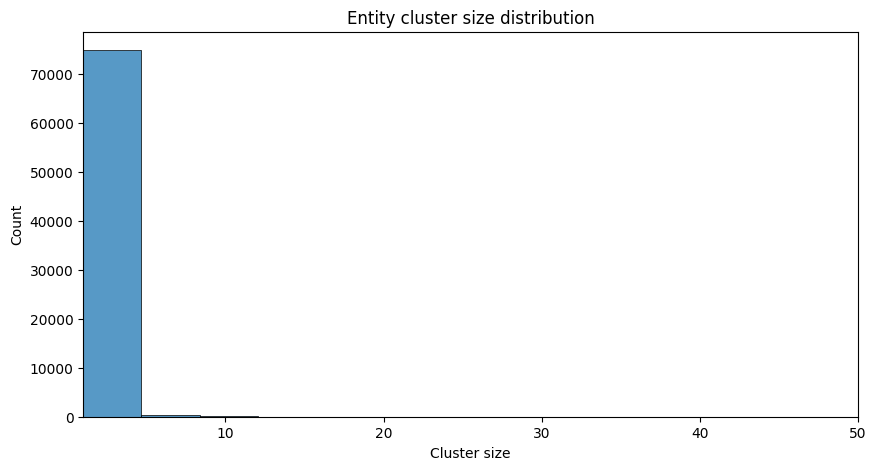

In [8]:
# ============================================================
# CLUSTER SIZE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    cluster_stats["cluster_size"],
    bins=100,
)

plt.xlim(1, 50)

plt.title("Entity cluster size distribution")
plt.xlabel("Cluster size")
plt.ylabel("Count")

plt.show()

In [9]:
# ============================================================
# LARGE CLUSTERS
# ============================================================

large_clusters = get_large_clusters(
    cluster_stats,
    min_size=20,
)

print(f"Large clusters: {len(large_clusters):,}")

display(large_clusters.head(20))

Large clusters: 54


,entity_id,cluster_size,unique_names,unique_countries,unique_scripts,unique_relation_kinds,unique_companies
3404,entity_00003404,369,1,1,1,1,3
3173,entity_00003173,274,1,1,1,1,1
4344,entity_00004344,274,1,1,1,1,3
442,entity_00000442,230,1,1,1,1,5
3688,entity_00003688,173,1,1,1,1,5
3402,entity_00003402,104,1,1,1,1,2
2426,entity_00002426,81,1,1,1,1,0
1853,entity_00001853,76,1,1,1,1,1
4266,entity_00004266,74,1,1,1,1,3
1845,entity_00001845,71,1,1,1,1,0


In [10]:
# ============================================================
# INSPECT LARGE CLUSTER EXAMPLES
# ============================================================

large_entity_ids = large_clusters["entity_id"].head(5).tolist()

for entity_id in large_entity_ids:
    print("=" * 80)
    print(f"entity_id: {entity_id}")

    subset = clustered_df[
        clustered_df["entity_id"] == entity_id
    ]

    print(f"Cluster size: {len(subset):,}")
    print(f"Canonical name: {subset['canonical_name'].iloc[0]}")

    display(
        subset[
            [
                "party_name",
                "name_latin",
                "country",
                "relation_kind",
                "relation_role",
                "company_name_norm",
            ]
        ]
        .drop_duplicates()
        .head(30)
    )

entity_id: entity_00003404
Cluster size: 369
Canonical name: neo metals holding limited


,party_name,name_latin,country,relation_kind,relation_role,company_name_norm
1853,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,neo metals holding limited,arm,shareholder,beneficial_owner,արդյունաբերական ընկերություն բը
1862,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,neo metals holding limited,arm,shareholder,beneficial_owner,պրոմիշլեննայա կոմպանիա
23418,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,neo metals holding limited,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ
24265,ՆԵՈ ՄԵՏԱԼՍ ՀՈԼԴԻՆԳ ԼԻՄԻԹԵԴ,neo metals holding limited,arm,shareholder,beneficial_owner,լեռ էքս


entity_id: entity_00003173
Cluster size: 274
Canonical name: mirzaaziz mousakhanov


,party_name,name_latin,country,relation_kind,relation_role,company_name_norm
814,Միրզաազիզ Մուսախանով,mirzaaziz mousakhanov,arm,shareholder,beneficial_owner,նեո մետալս հոլդինգ լիմիթեդ
2456,Միրզաազիզ Մուսախանով,mirzaaziz mousakhanov,arm,shareholder,beneficial_owner,ստարտ աէրո սպը
3714,Միրզաազիզ Մուսախանով,mirzaaziz mousakhanov,arm,shareholder,beneficial_owner,նեո մետալս հոլդինգ լիմիթեդ բաժնետոմսերով սահմա...
9032,Միրզաազիզ Մուսախանով,mirzaaziz mousakhanov,arm,shareholder,beneficial_owner,արդրոս օվերսիզ լիմիթեդ


entity_id: entity_00004344
Cluster size: 274
Canonical name: svetlana ershova


,party_name,name_latin,country,relation_kind,relation_role,company_name_norm
493,Սվետլանա Երշովա,svetlana ershova,arm,shareholder,beneficial_owner,նեո մետալս հոլդինգ լիմիթեդ
1790,Սվետլանա Երշովա,svetlana ershova,arm,shareholder,beneficial_owner,նեո մետալս հոլդինգ լիմիթեդ բաժնետոմսերով սահմա...
11112,Սվետլանա Երշովա,svetlana ershova,arm,shareholder,beneficial_owner,անհայտ կազմակերպություն


entity_id: entity_00000442
Cluster size: 230
Canonical name: ardyounaberakan ynkeroutyoun by


,party_name,name_latin,country,relation_kind,relation_role,company_name_norm
922,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,arm,shareholder,beneficial_owner,սթար դասթ փբը
951,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,arm,shareholder,beneficial_owner,ամփ հոլդինգս փբը
2857,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,arm,shareholder,beneficial_owner,ուրբանեվենտ պլյուս սպը
4729,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ
15362,ԱՐԴՅՈՒՆԱԲԵՐԱԿԱՆ ԸՆԿԵՐՈՒԹՅՈՒՆ ԲԸ,ardyounaberakan ynkeroutyoun by,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ փբը


entity_id: entity_00003688
Cluster size: 173
Canonical name: promishlennaya kompania


,party_name,name_latin,country,relation_kind,relation_role,company_name_norm
794,ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ,promishlennaya kompania,arm,shareholder,beneficial_owner,ուրբանեվենտ պլյուս սպը
972,ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ,promishlennaya kompania,arm,shareholder,beneficial_owner,ամփ հոլդինգս փբը
1725,Պրոմիշլեննայա կոմպանիա,promishlennaya kompania,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ
2606,ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ,promishlennaya kompania,arm,shareholder,beneficial_owner,սթար դասթ փբը
6706,ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ,promishlennaya kompania,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ փբը
17221,Պրոմիշլեննայա կոմպանիա,promishlennaya kompania,arm,shareholder,beneficial_owner,ուրբանեվենտ պլյուս սպը
27721,ՊՐՈՄԻՇԼԵՆՆԱՅԱ ԿՈՄՊԱՆԻԱ,promishlennaya kompania,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ
73238,Պրոմիշլեննայա կոմպանիա,promishlennaya kompania,arm,shareholder,beneficial_owner,սթար դասթ փբը
78280,Պրոմիշլեննայա կոմպանիա,promishlennaya kompania,arm,shareholder,beneficial_owner,զանգեզուրի պղնձամոլիբդենային կոմբինատ փբը


In [11]:
# ============================================================
# SUSPICIOUS CLUSTERS
# ============================================================

suspicious_clusters = get_suspicious_clusters(
    cluster_stats,
    max_unique_names=5,
    max_unique_countries=3,
)

print(f"Suspicious clusters: {len(suspicious_clusters):,}")

display(suspicious_clusters.head(20))

Suspicious clusters: 2


,entity_id,cluster_size,unique_names,unique_countries,unique_scripts,unique_relation_kinds,unique_companies
892,entity_00000892,12,10,1,1,3,11
3145,entity_00003145,7,6,1,1,1,7


In [12]:
# ============================================================
# INSPECT SUSPICIOUS CLUSTERS
# ============================================================

suspicious_entity_ids = suspicious_clusters["entity_id"].head(5).tolist()

for entity_id in suspicious_entity_ids:
    print("=" * 80)
    print(f"entity_id: {entity_id}")

    subset = clustered_df[
        clustered_df["entity_id"] == entity_id
    ]

    print(f"Cluster size: {len(subset):,}")
    print(f"Canonical name: {subset['canonical_name'].iloc[0]}")
    print(f"Unique names: {subset['name_latin'].nunique()}")
    print(f"Unique countries: {subset['country'].nunique()}")

    display(
        subset[
            [
                "party_name",
                "name_latin",
                "country",
                "relation_kind",
                "relation_role",
            ]
        ]
        .drop_duplicates()
        .head(50)
    )

entity_id: entity_00000892
Cluster size: 12
Canonical name: batbayar ganbayar
Unique names: 10
Unique countries: 1


,party_name,name_latin,country,relation_kind,relation_role
11896,ганбаяр батбаяр,ganbayar batbayar,mng,shareholder,shareholder
18462,батбаяр ганбаяр,batbayar ganbayar,mng,shareholder,shareholder
34852,Анхбаяр Батбаяр,anhbayar batbayar,mng,ubo,ubo
37193,батбаяр анхбаатар,batbayar anhbaatar,mng,shareholder,shareholder
55756,Энхбаяр Батбаяр,enhbayar batbayar,mng,ubo,ubo
56094,батбаяр мөнхбаатар,batbayar monhbaatar,mng,shareholder,shareholder
59583,Батбаяр Энхбаяр,batbayar enhbayar,mng,ubo,ubo
63498,Батбаяр Анхбаяр,batbayar anhbayar,mng,director,Захирал
70471,батбаяр энхбаатар,batbayar enhbaatar,mng,shareholder,shareholder
84035,энхбаатар батбаяр,enhbaatar batbayar,mng,shareholder,shareholder


entity_id: entity_00003145
Cluster size: 7
Canonical name: ministerstvo obrazovaniya inauki kyrgyzskoi respubliki
Unique names: 6
Unique countries: 1


,party_name,name_latin,country,relation_kind,relation_role
8610,Министерство образования инауки Кыргызской Рес...,ministerstvo obrazovaniya inauki kyrgyzskoi re...,kgz,shareholder,founder
12836,Министрество образование и науки кыргызской Ре...,ministrestvo obrazovanie i nauki kyrgyzskoi re...,kgz,shareholder,founder
16109,Министерство образование и науки Кыргызкой Рес...,ministerstvo obrazovanie i nauki kyrgyzkoi res...,kgz,shareholder,founder
31199,Министерств образования и науки Кыргызской Рес...,ministerstv obrazovaniya i nauki kyrgyzskoi re...,kgz,shareholder,founder
42898,Министерство науки и образование Кыргызской Ре...,ministerstvo nauki i obrazovanie kyrgyzskoi re...,kgz,shareholder,founder
58375,Министерство образование и науки Кыргызской ре...,ministerstvo obrazovanie i nauki kyrgyzskoi re...,kgz,shareholder,founder


In [13]:
# ============================================================
# SAVE CLUSTERED SAMPLE
# ============================================================

clustered_df.to_parquet(
    "../data/processed/clustered_sample.parquet",
    index=False,
)

cluster_stats.to_parquet(
    "../data/processed/cluster_stats_sample.parquet",
    index=False,
)

print("Saved:")
print("../data/processed/clustered_sample.parquet")
print("../data/processed/cluster_stats_sample.parquet")

Saved:
../data/processed/clustered_sample.parquet
../data/processed/cluster_stats_sample.parquet
